In [5]:
import numpy as np
import pandas as pd
from kneed import KneeLocator
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from mrmr import mrmr_classif
from mrmr import mrmr_regression
from feature_engine.selection import MRMR
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import mutual_info_classif

🔵 MRMR -> mrmr_selection - STAGE (without significant filtration)

100%|██████████| 10/10 [00:00<00:00, 33.13it/s]


Top 10 MRMR features (mrmr_selection):
1. original_glcm_JointEntropy
2. gradient_glcm_Correlation
3. n_lesions
4. original_firstorder_Kurtosis
5. original_glcm_Contrast
6. original_glcm_MaximumProbability
7. gradient_glcm_Imc2
8. original_glcm_DifferenceAverage
9. original_glcm_DifferenceEntropy
10. original_glcm_Id


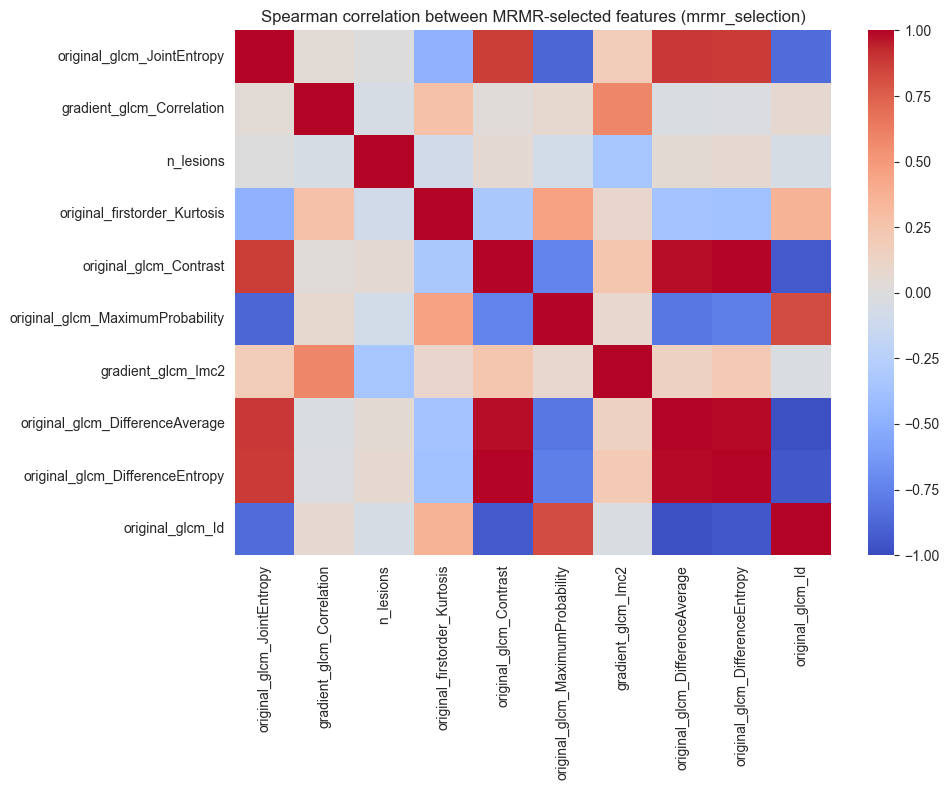

In [36]:
pd.set_option('future.no_silent_downcasting', True)
# Radiomic features
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# Clinical Biomarkers
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

# Merge datasets
merged_df = pd.merge(features_df, clinical_df[['Patient ID', 'Stage']],
                     left_on='patient', right_on='Patient ID', how='inner')

# Numeric features
numeric_features = merged_df.select_dtypes(include=['number']).columns
X = merged_df[numeric_features].drop(columns=['Stage'], errors='ignore')
y = merged_df['Stage']

# Drop rows with NaN
valid_idx = X.notna().all(axis=1) & y.notna()
X, y = X[valid_idx], y[valid_idx]

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# MRMR selection
df_mrmr = X_scaled.copy()
df_mrmr['Stage'] = y.values
selected_features = mrmr_classif(X=df_mrmr.drop(columns='Stage'), y=df_mrmr['Stage'], K=10)

print("Top 10 MRMR features (mrmr_selection):")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

# Correlation matrix
selected_df = X_scaled[selected_features]
corr_matrix = selected_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title("Spearman correlation between MRMR-selected features (mrmr_selection)")
plt.tight_layout()
plt.show()

🔵 MRMR -> feature-engine - STAGE (without significant filtration)

Top 10 MRMR features (feature-engine):
1. original_shape_Elongation
2. original_shape_SurfaceVolumeRatio
3. original_firstorder_Kurtosis
4. original_firstorder_TotalEnergy
5. original_glrlm_LongRunHighGrayLevelEmphasis
6. original_glszm_ZoneEntropy
7. original_gldm_DependenceVariance
8. gradient_firstorder_Maximum
9. gradient_glcm_Contrast
10. gradient_glcm_Correlation


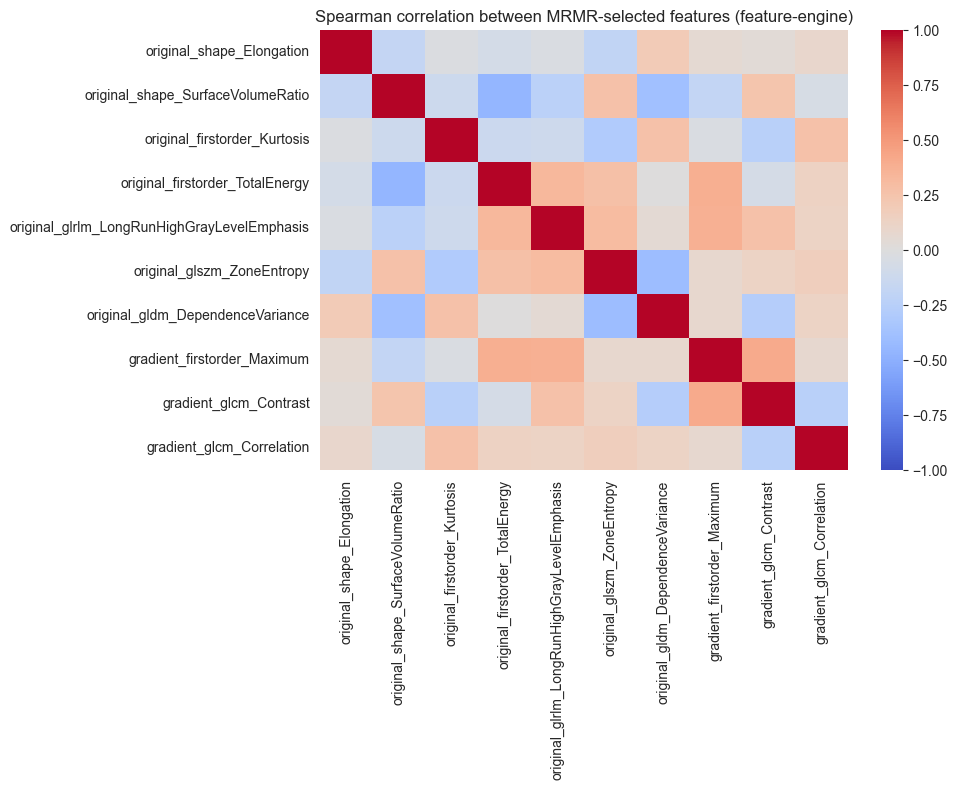

In [37]:
pd.set_option('future.no_silent_downcasting', True)
# Radiomic features
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# Clinical Biomarkers
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

# Merge datasets
merged_df = pd.merge(features_df, clinical_df[['Patient ID', 'Stage']],
                     left_on='patient', right_on='Patient ID', how='inner')

# Numeric features
numeric_features = merged_df.select_dtypes(include=['number']).columns
X = merged_df[numeric_features].drop(columns=['Stage'], errors='ignore')
y = merged_df['Stage']

# Drop rows with NaN
valid_idx = X.notna().all(axis=1) & y.notna()
X, y = X[valid_idx], y[valid_idx]
y = y.astype(int)

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# MRMR selection
selector = MRMR(method='MIQ', max_features=10)
selector.fit(X_scaled, y)
X_selected = selector.transform(X_scaled)
selected_features = X_selected.columns.tolist()

print("Top 10 MRMR features (feature-engine):")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

# Correlation matrix
corr_matrix = X_selected.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title("Spearman correlation between MRMR-selected features (feature-engine)")
plt.tight_layout()
plt.show()

🔵 MRMR -> mrmr_selection - B2 MICROGLOBULIN (without significant filtration)

100%|██████████| 10/10 [00:00<00:00, 27.14it/s]


Top 10 MRMR features (mrmr_selection regression):
1. original_firstorder_10Percentile
2. original_gldm_SmallDependenceEmphasis
3. original_firstorder_Energy
4. original_gldm_LargeDependenceLowGrayLevelEmphasis
5. original_firstorder_Kurtosis
6. original_shape_MajorAxisLength
7. original_firstorder_Maximum
8. gradient_gldm_LargeDependenceLowGrayLevelEmphasis
9. original_firstorder_TotalEnergy
10. gradient_firstorder_Median


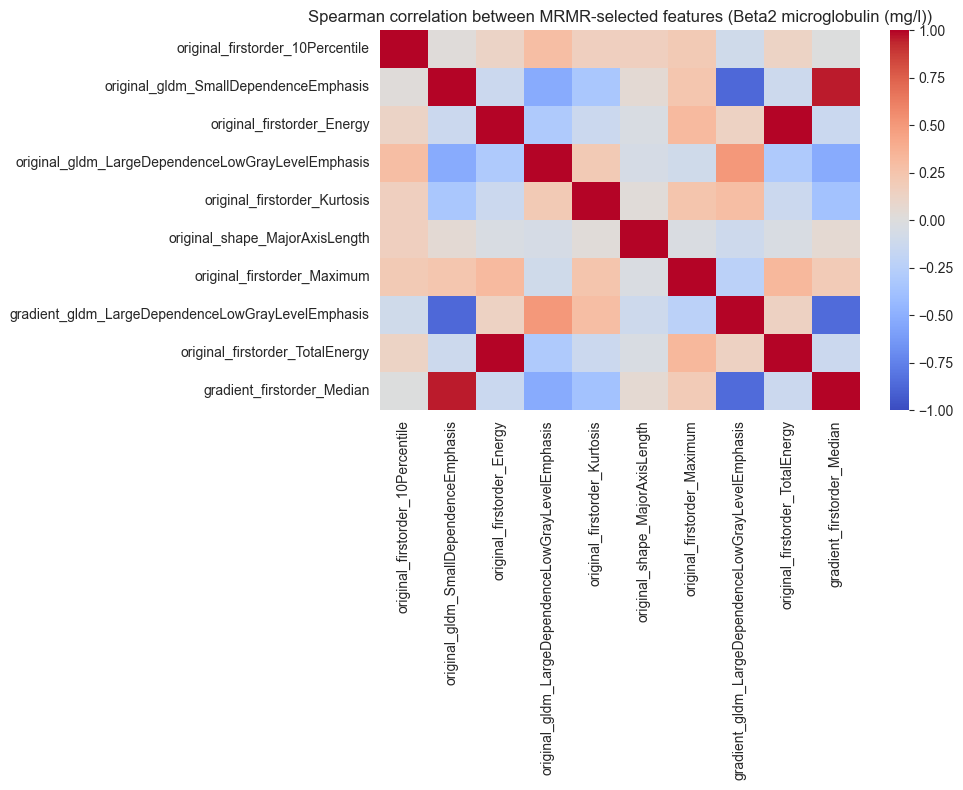

In [38]:
pd.set_option('future.no_silent_downcasting', True)
# Radiomic features
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# Clinical Biomarkers
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_column = 'Beta2 microglobulin (mg/l)'

# Merge datasets
merged_df = pd.merge(features_df, clinical_df[['Patient ID', clinical_column]],
                     left_on='patient', right_on='Patient ID', how='inner')

# Numeric features
numeric_features = merged_df.select_dtypes(include=['number']).columns
X = merged_df[numeric_features].drop(columns=[clinical_column], errors='ignore')
y = merged_df[clinical_column]

# Drop rows with NaN
valid_idx = X.notna().all(axis=1) & y.notna()
X, y = X[valid_idx], y[valid_idx]

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# MRMR regression
df_mrmr = X_scaled.copy()
df_mrmr[clinical_column] = y.values
selected_features = mrmr_regression(df_mrmr.drop(columns=clinical_column), df_mrmr[clinical_column], K=10)

print("Top 10 MRMR features (mrmr_selection regression):")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

# Correlation matrix
selected_df = X_scaled[selected_features]
corr_matrix = selected_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title(f"Spearman correlation between MRMR-selected features ({clinical_column})")
plt.tight_layout()
plt.show()

🔵 MRMR -> mrmr_selection - STAGE (JUST SIGNIFICANT FEATURES)

100%|██████████| 10/10 [00:00<00:00, 33.30it/s]


Top 10 MRMR features (mrmr_selection):
1. original_glcm_JointEntropy
2. gradient_glcm_Correlation
3. original_firstorder_Kurtosis
4. original_glcm_Contrast
5. gradient_glcm_Imc2
6. original_glcm_MaximumProbability
7. original_glcm_DifferenceAverage
8. original_glcm_DifferenceEntropy
9. original_glcm_Id
10. original_firstorder_InterquartileRange


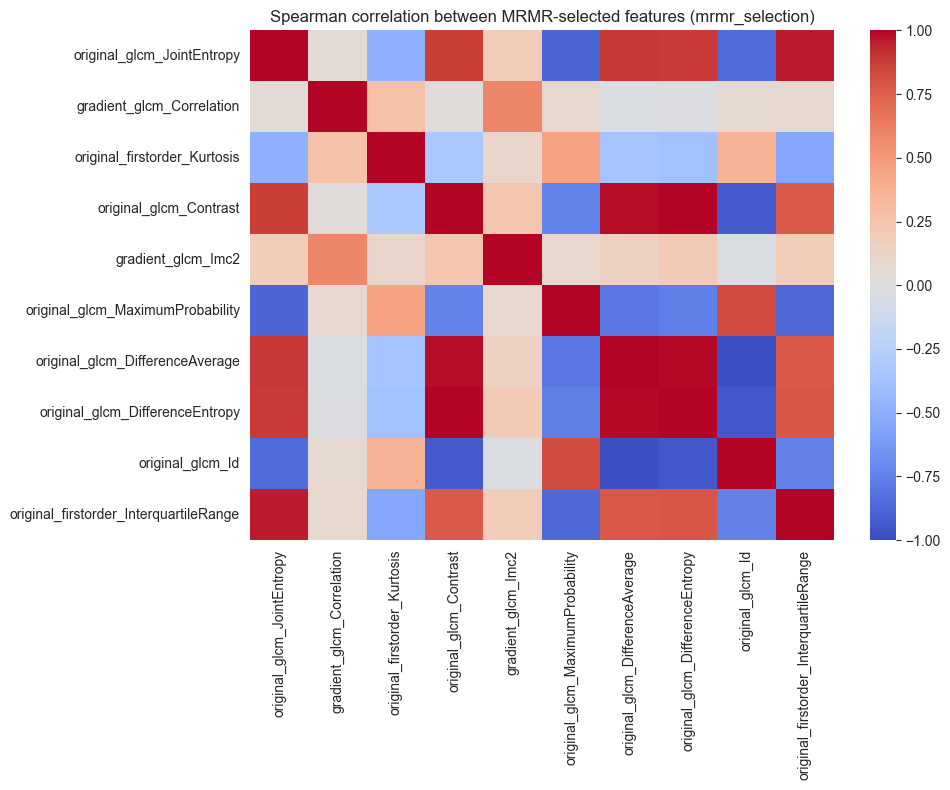

In [39]:
# Load datasets and significant features
kw_vmi40_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi40.csv")
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
significant_features = kw_vmi40_df.loc[kw_vmi40_df['p_all'] < 0.05, 'Feature']

clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

# Merge datasets
merged_df = pd.merge(features_df, clinical_df[['Patient ID', 'Stage']],
                     left_on='patient', right_on='Patient ID', how='inner')

# Numeric features
X = merged_df[significant_features].drop(columns=['Stage'], errors='ignore')
y = merged_df['Stage']

# Drop rows with NaN
valid_idx = X.notna().all(axis=1) & y.notna()
X, y = X[valid_idx], y[valid_idx]

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# MRMR selection
df_mrmr = X_scaled.copy()
df_mrmr['Stage'] = y.values
selected_features = mrmr_classif(X=df_mrmr.drop(columns='Stage'), y=df_mrmr['Stage'], K=10)

print("Top 10 MRMR features (mrmr_selection):")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

# Correlation matrix
selected_df = X_scaled[selected_features]
corr_matrix = selected_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title("Spearman correlation between MRMR-selected features (mrmr_selection)")
plt.tight_layout()
plt.show()

🔵 MRMR -> feature_engine - STAGE (JUST SIGNIFICANT FEATURES)

Top 10 MRMR features (feature-engine):
1. original_firstorder_Kurtosis
2. original_firstorder_Skewness
3. original_glcm_Autocorrelation
4. original_glcm_Id
5. original_glcm_Idmn
6. original_glszm_ZoneEntropy
7. gradient_glcm_Correlation
8. gradient_glszm_GrayLevelVariance
9. gradient_glszm_ZoneEntropy
10. gradient_ngtdm_Contrast


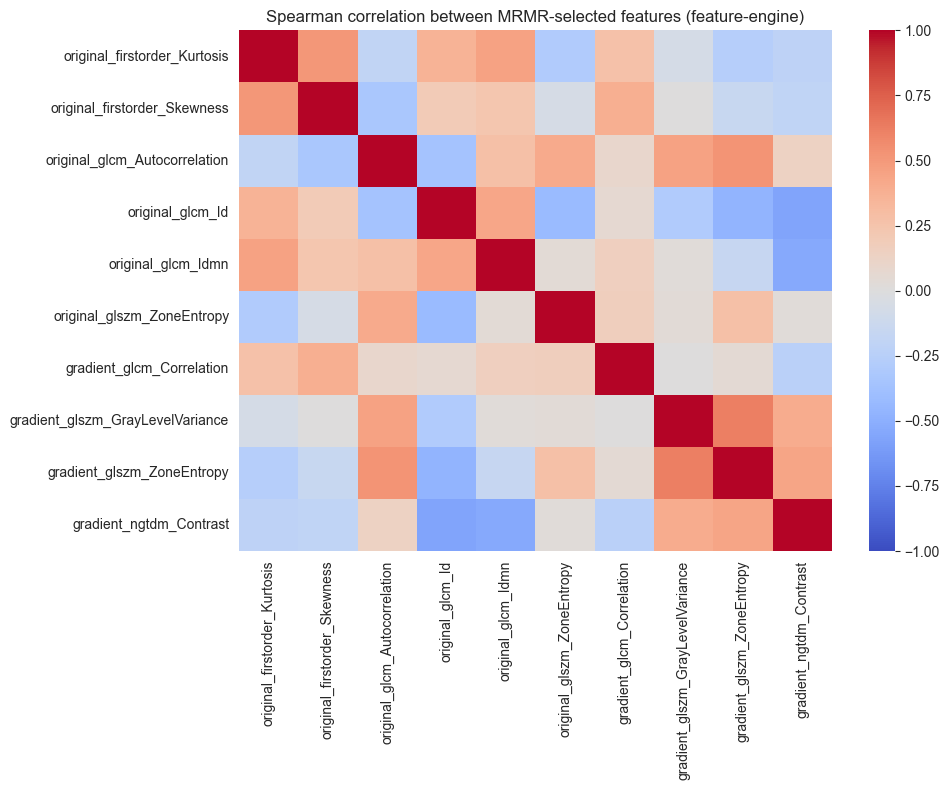

In [40]:
# Load datasets and significant features
kw_vmi40_df = pd.read_csv(r"D:\CSV\kruskal_wallis\kruskal-wallis_vmi40.csv")
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
significant_features = kw_vmi40_df.loc[kw_vmi40_df['p_all'] < 0.05, 'Feature']

clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

# Merge datasets
merged_df = pd.merge(features_df, clinical_df[['Patient ID', 'Stage']],
                     left_on='patient', right_on='Patient ID', how='inner')

# Numeric features
X = merged_df[significant_features].drop(columns=['Stage'], errors='ignore')
y = merged_df['Stage']

# Drop rows with NaN
valid_idx = X.notna().all(axis=1) & y.notna()
X, y = X[valid_idx], y[valid_idx]
y = y.astype(int)

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# MRMR selection
selector = MRMR(method='MIQ', max_features=10)
selector.fit(X_scaled, y)
X_selected = selector.transform(X_scaled)
selected_features = X_selected.columns.tolist()

print("Top 10 MRMR features (feature-engine):")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

# Correlation matrix
corr_matrix = X_selected.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title("Spearman correlation between MRMR-selected features (feature-engine)")
plt.tight_layout()
plt.show()

🔵 MRMR -> mrmr_selection - B2 MICROGLOBULIN (JUST SIGNIFICANT FEATURES)

100%|██████████| 10/10 [00:00<00:00, 30.88it/s]


Top 10 MRMR features (mrmr_selection regression):
1. original_gldm_LargeDependenceLowGrayLevelEmphasis
2. original_glcm_Idn
3. original_glszm_ZoneEntropy
4. gradient_glcm_Contrast
5. gradient_glcm_Imc1
6. original_firstorder_Kurtosis
7. original_glszm_LargeAreaLowGrayLevelEmphasis
8. original_glrlm_LongRunLowGrayLevelEmphasis
9. gradient_gldm_DependenceNonUniformityNormalized
10. gradient_gldm_LargeDependenceLowGrayLevelEmphasis


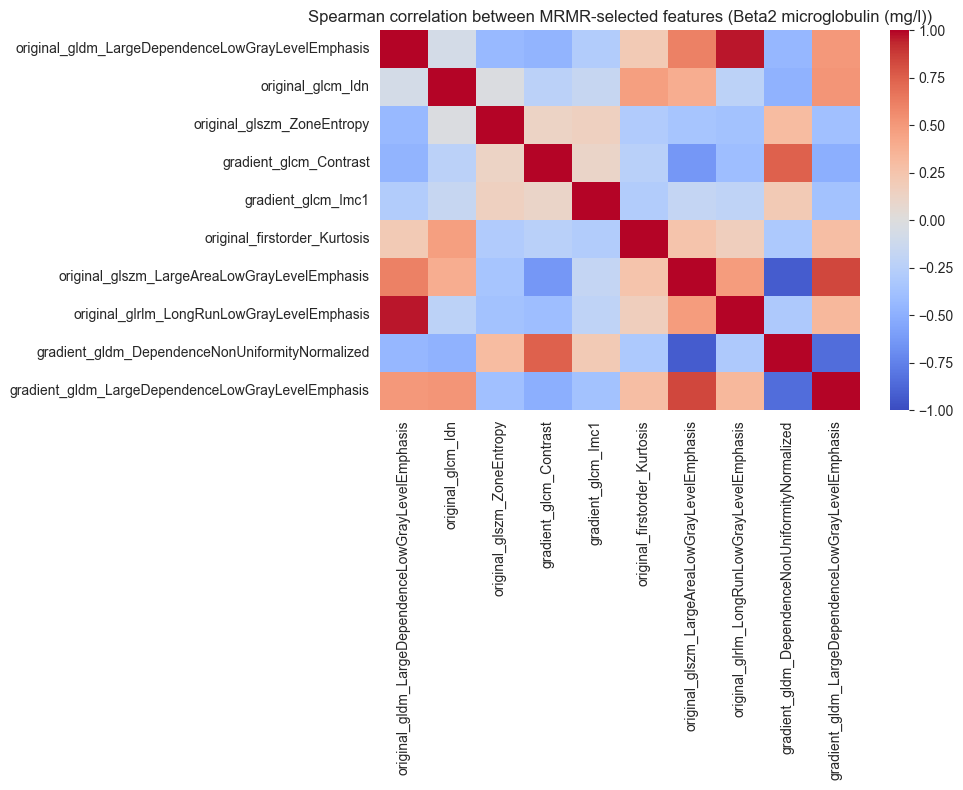

In [41]:
# Load datasets and significant features
spearman_vmi40_df = pd.read_csv(r"D:\CSV\spearman_coef\spearman_results_vmi40.csv")
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
significant_features = spearman_vmi40_df.loc[spearman_vmi40_df['p_value'] < 0.05, 'Feature']
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_column = 'Beta2 microglobulin (mg/l)'

# Merge datasets
merged_df = pd.merge(features_df, clinical_df[['Patient ID', clinical_column]],
                     left_on='patient', right_on='Patient ID', how='inner')

# Numeric features
X = merged_df[significant_features].drop(columns=[clinical_column], errors='ignore')
y = merged_df[clinical_column]

# Drop rows with NaN
valid_idx = X.notna().all(axis=1) & y.notna()
X, y = X[valid_idx], y[valid_idx]

# Standardization
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# MRMR regression
df_mrmr = X_scaled.copy()
df_mrmr[clinical_column] = y.values
selected_features = mrmr_regression(df_mrmr.drop(columns=clinical_column), df_mrmr[clinical_column], K=10)

print("Top 10 MRMR features (mrmr_selection regression):")
for i, f in enumerate(selected_features, 1):
    print(f"{i}. {f}")

# Correlation matrix
selected_df = X_scaled[selected_features]
corr_matrix = selected_df.corr(method='spearman')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)
plt.title(f"Spearman correlation between MRMR-selected features ({clinical_column})")
plt.tight_layout()
plt.show()

🔵 MUTUAL INFORMATION (B2 MICROGLOBULIN)

NOTES:
- how closely related two variables are
- calculation is based on Joint Probabilities and Marginal Probabilities
- continuous values are calculated as bins of histogram
- MI tells us how, on average, the surprise, or change, we see in one variable is related to the surprise, or change, in another.

                                               Feature        MI
0                           original_glrlm_RunVariance  0.377175
1                original_gldm_LargeDependenceEmphasis  0.351175
2      original_gldm_DependenceNonUniformityNormalized  0.325029
3    gradient_gldm_LargeDependenceLowGrayLevelEmphasis  0.322861
4                             original_glcm_SumSquares  0.268439
..                                                 ...       ...
196               gradient_glszm_SizeZoneNonUniformity  0.000000
197      gradient_glszm_LargeAreaHighGrayLevelEmphasis  0.000000
198  gradient_gldm_LargeDependenceHighGrayLevelEmph...  0.000000
199                          gradient_ngtdm_Coarseness  0.000000
200                            gradient_ngtdm_Strength  0.000000

[201 rows x 2 columns]
Selected features: ['original_glrlm_RunVariance', 'original_gldm_LargeDependenceEmphasis', 'original_gldm_DependenceNonUniformityNormalized', 'gradient_gldm_LargeDependenceLowGrayLevelEmphasis', '

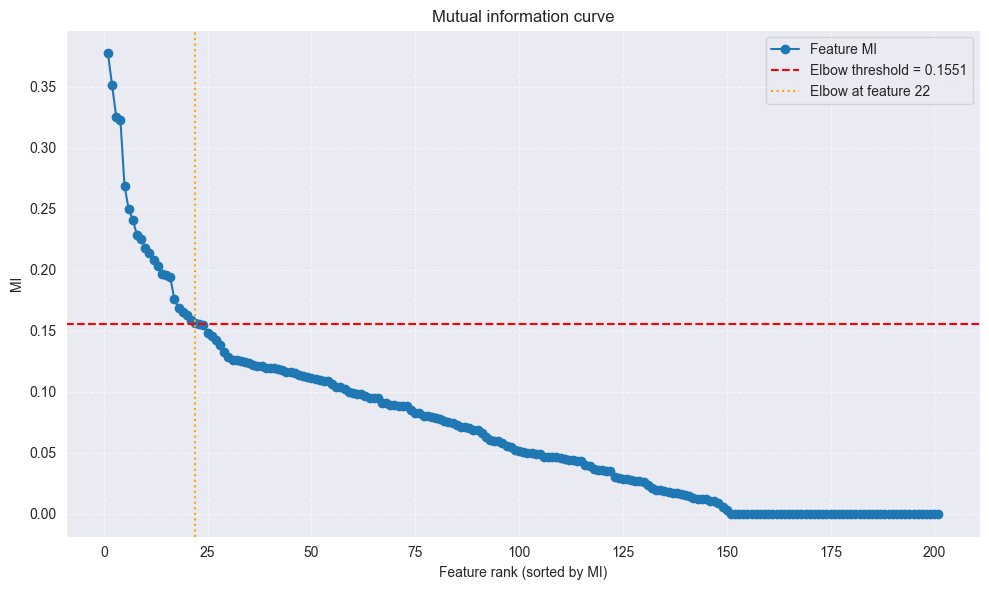

In [6]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_column = 'Beta2 microglobulin (mg/l)'

features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
numeric_features = features_df.select_dtypes(include=['number']).columns

mutual_info_list = []
for col in numeric_features:
    valid_idx = features_df[col].notna() & clinical_df[clinical_column].notna()

    X = features_df[[col]][valid_idx]
    y = clinical_df[clinical_column][valid_idx]

    mi = mutual_info_regression(X, y)[0]
    mutual_info_list.append({'Feature': col, 'MI': mi})

mutual_information_df = pd.DataFrame(mutual_info_list).sort_values(by='MI', ascending=False).reset_index(drop=True)
print(mutual_information_df)

imp = np.sort(mutual_information_df['MI'].values)[::-1]
x = np.arange(1, len(imp) + 1)

knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
threshold = imp[knee.knee] if knee.knee is not None else None
selected_features = mutual_information_df[mutual_information_df['MI'] > threshold]['Feature'].tolist()
print(f"Selected features: {selected_features}")

plt.figure(figsize=(10, 6))
plt.plot(x, imp, marker='o', label='Feature MI')
if threshold is not None:
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
    plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
plt.title(f"Mutual information curve")
plt.xlabel("Feature rank (sorted by MI)")
plt.ylabel("MI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

🔵 MUTUAL INFORMATION (STAGE)

                                               Feature        MI
0                      original_glcm_DifferenceAverage  0.233909
1                         original_firstorder_Kurtosis  0.220808
2                     original_glcm_MaximumProbability  0.206871
3                                    original_glcm_Idm  0.195939
4                           gradient_firstorder_Median  0.194631
..                                                 ...       ...
196               gradient_gldm_GrayLevelNonUniformity  0.000000
197  gradient_gldm_LargeDependenceHighGrayLevelEmph...  0.000000
198  gradient_gldm_SmallDependenceLowGrayLevelEmphasis  0.000000
199                          gradient_ngtdm_Coarseness  0.000000
200                            gradient_ngtdm_Strength  0.000000

[201 rows x 2 columns]
Selected features: ['original_glcm_DifferenceAverage', 'original_firstorder_Kurtosis', 'original_glcm_MaximumProbability', 'original_glcm_Idm', 'gradient_firstorder_Median', 'original_glcm_SumSqua

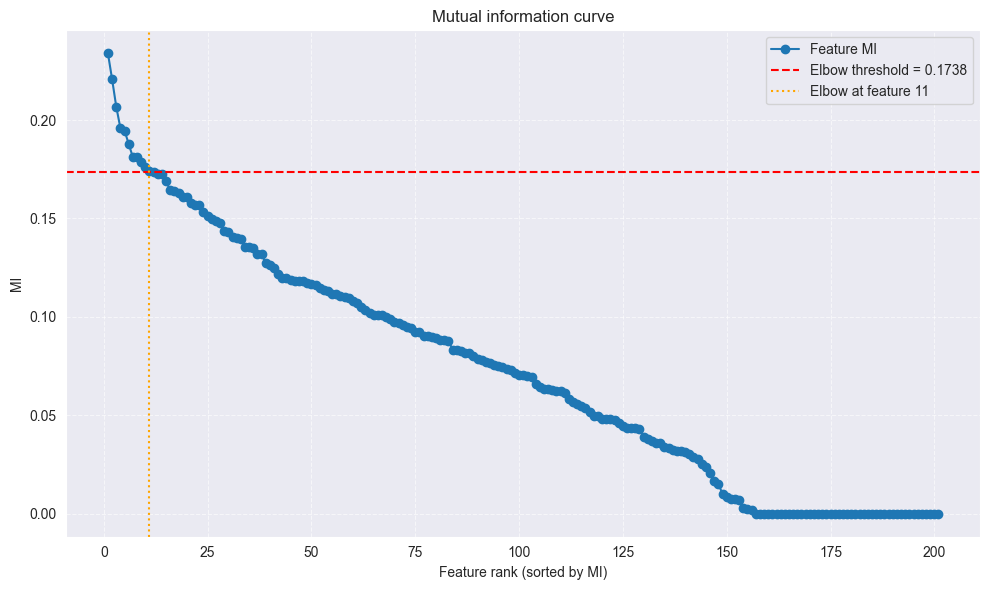

In [7]:
features_df = pd.read_csv(r"D:\CSV\merged\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})
clinical_column = 'Stage'
numeric_features = features_df.select_dtypes(include=['number']).columns

mutual_info_list = []
for col in numeric_features:
    valid_idx = features_df[col].notna() & clinical_df[clinical_column].notna()

    X = features_df[[col]][valid_idx]
    y = clinical_df[clinical_column][valid_idx]

    mi = mutual_info_regression(X, y)[0]
    mutual_info_list.append({'Feature': col, 'MI': mi})

mutual_information_df = pd.DataFrame(mutual_info_list).sort_values(by='MI', ascending=False).reset_index(drop=True)
print(mutual_information_df)

imp = np.sort(mutual_information_df['MI'].values)[::-1]
x = np.arange(1, len(imp) + 1)

knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
threshold = imp[knee.knee] if knee.knee is not None else None
selected_features = mutual_information_df[mutual_information_df['MI'] > threshold]['Feature'].tolist()
print(f"Selected features: {selected_features}")

plt.figure(figsize=(10, 6))
plt.plot(x, imp, marker='o', label='Feature MI')
if threshold is not None:
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
    plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
plt.title(f"Mutual information curve")
plt.xlabel("Feature rank (sorted by MI)")
plt.ylabel("MI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

🔵 MUTUAL INFORMATION BETWEEN EVERY CLINICAL BIOMARKER AND STAGE

                            Feature        MI
0        Beta2 microglobulin (mg/l)  0.962168
1  Serum lambda FLC quantity (mg/l)  0.229085
2                IgG quantity (g/l)  0.180448
3                IgM quantity (g/l)  0.135888
4    Serum M-protein quantity (g/l)  0.134228
5    Serum kappa FLC quantity (mg/l  0.118997
6      Calcium total level (mmol/l)  0.104909
7         Creatinine level (µmol/l)  0.088356
8                IgA quantity (g/l)  0.058174
9           Plasmocyte count FC (%)  0.007332
Selected features: ['Beta2 microglobulin (mg/l)', 'Serum lambda FLC quantity (mg/l)']


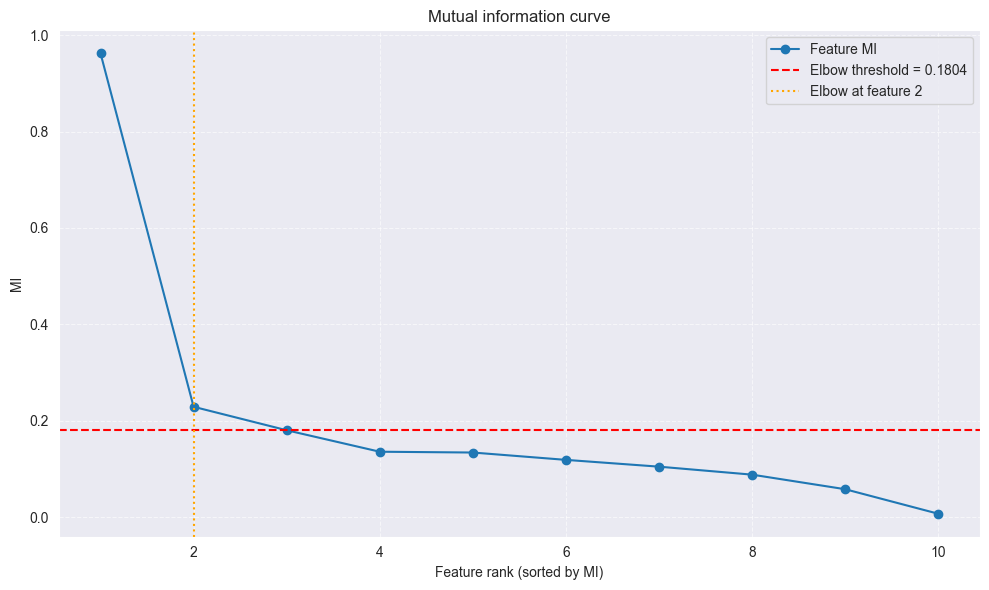

In [8]:
clinical_df = pd.read_csv(r"D:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
numeric_features = clinical_df.select_dtypes(include=['number']).columns
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})
clinical_column = 'Stage'

mutual_info_list = []
for col in numeric_features:
    valid_idx = clinical_df[col].notna() & clinical_df[clinical_column].notna()

    X = clinical_df.loc[valid_idx, [col]]
    y = clinical_df.loc[valid_idx, clinical_column]
    y = y.astype(int)

    mi = mutual_info_classif(X, y, discrete_features=False)[0]
    mutual_info_list.append({'Feature': col, 'MI': mi})

mutual_information_df = pd.DataFrame(mutual_info_list).sort_values(by='MI', ascending=False).reset_index(drop=True)
print(mutual_information_df)

imp = np.sort(mutual_information_df['MI'].values)[::-1]
x = np.arange(1, len(imp) + 1)

knee = KneeLocator(x, imp, curve='convex', direction='decreasing')
threshold = imp[knee.knee] if knee.knee is not None else None
selected_features = mutual_information_df[mutual_information_df['MI'] > threshold]['Feature'].tolist()
print(f"Selected features: {selected_features}")

plt.figure(figsize=(10, 6))
plt.plot(x, imp, marker='o', label='Feature MI')
if threshold is not None:
    plt.axhline(y=threshold, color='red', linestyle='--', label=f'Elbow threshold = {threshold:.4f}')
    plt.axvline(x=knee.knee, color='orange', linestyle=':', label=f'Elbow at feature {knee.knee}')
plt.title(f"Mutual information curve")
plt.xlabel("Feature rank (sorted by MI)")
plt.ylabel("MI")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()